In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# --- 0. Setup ---
# [GPU FIX 1]: Unleashed the GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = "cpu"
print(f"Using device: {device}")

# --- 1. Environment Parameters ---
K = 300  # Number of devices
r_cvge = 400 # BS coverage - 400m 
P = 5 # Maximum symbol power [dBm] 
sigma_z2 = -50 # Effective noise power [dBm]
gamma = -10 # Coefficient for power scaling [dB]

# Linear Scale Conversions
P_mW = 10 ** (P / 10.0)
sigma_z2_mW = 10 ** (sigma_z2 / 10.0)
gamma_lin = 10 ** (gamma / 10.0)

F = 1024 # Number of sub-channels
alpha = 4 # Path loss exponent
M_0 = 200 # BS dataset size [samples]

lr = 0.05 # Learning rate
batch_size = 10 # Mini-batch size in local training
epoch = 3 # Local training epoch
D = 582026 # Number of DNN parameters

T_th = 0.5 * (r_cvge ** (-alpha)) # Truncation threshold

# --- 2. Model Architecture ---
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 5), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 5), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(nn.Linear(64 * 4 * 4, 512), nn.ReLU(), nn.Linear(512, 10))
    def forward(self, x):
        x = self.conv(x)
        return self.fc(x.view(x.size(0), -1))

# --- 3. Data Preparation ---
def get_dataset(K=300, M_0=200, mean_size=200):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    all_indices = np.arange(len(train_dataset))
    np.random.shuffle(all_indices)

    bs_indices = all_indices[:M_0]
    bs_dataset = Subset(train_dataset, bs_indices)

    remaining_indices = all_indices[M_0:]
    targets = train_dataset.targets.numpy()

    class_indices = {i: [] for i in range(10)}
    for idx in remaining_indices:
        class_indices[targets[idx]].append(idx)

    for i in range(10): np.random.shuffle(class_indices[i])

    client_datasets = []
    for k in range(K):
        N_k = max(10, np.random.poisson(mean_size))
        selected_classes = np.random.choice(10, 3, replace=False)

        samples_per_class = [N_k // 3] * 3
        for i in range(N_k % 3): samples_per_class[i] += 1

        client_indices = []
        for c, num_samples in zip(selected_classes, samples_per_class):
            if len(class_indices[c]) >= num_samples:
                client_indices.extend(class_indices[c][:num_samples])
                class_indices[c] = class_indices[c][num_samples:]
            else:
                client_indices.extend(class_indices[c])
                deficit = num_samples - len(class_indices[c])
                class_indices[c] = []
                all_c_indices = [idx for idx in remaining_indices if targets[idx] == c]
                client_indices.extend(np.random.choice(all_c_indices, deficit, replace=True))

        np.random.shuffle(client_indices)
        client_datasets.append(Subset(train_dataset, client_indices))

    return bs_dataset, client_datasets, test_dataset

# --- 4. Local Training Functions ---
# [GPU FIX 2]: Pass in 'local_model' to avoid creating new ones in VRAM
def local_update(global_model, local_model, local_dataset, lr=0.05, batch_size=10, epochs=3):
    local_model.load_state_dict(global_model.state_dict())
    local_model.train()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(local_model.parameters(), lr=lr)
    train_loader = DataLoader(local_dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = local_model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    return local_model.state_dict()

def get_flattened_delta(global_state_dict, local_state_dict):
    delta_list = []
    for key in global_state_dict.keys():
        diff = local_state_dict[key] - global_state_dict[key]
        delta_list.append(diff.view(-1))
    return torch.cat(delta_list)

def apply_flattened_update(global_model, aggregated_delta_flat):
    new_state_dict = global_model.state_dict()
    current_index = 0
    for key in new_state_dict.keys():
        param_shape = new_state_dict[key].shape
        num_params = new_state_dict[key].numel()
        layer_delta = aggregated_delta_flat[current_index : current_index + num_params].view(param_shape)
        new_state_dict[key] += layer_delta
        current_index += num_params
    global_model.load_state_dict(new_state_dict)

# --- 5. TCI-based power control (Standard Independent Baseline) ---
def tci_power_allocation(u_arg, delta_arg, abs_h_sq, T_th, P_arg):
    # --- The Hidden Private Code: Device-Level Outage ---
    # If the average channel gain of the device is below the threshold,
    # the Base Station rejects the connection entirely.
    avg_h_sq = torch.mean(abs_h_sq)
    if avg_h_sq < T_th:
        return torch.zeros_like(delta_arg) # The device drops completely!
    
    # Otherwise, proceed with the standard independent subcarrier clamping
    rho = delta_arg ** 2
    p_ideal = u_arg * rho
    
    mask = abs_h_sq >= T_th
    p_out = torch.zeros_like(p_ideal)
    
    F_subchannels = p_ideal.shape[1]
    max_power_per_subchannel = P_arg / F_subchannels
    
    p_out[mask] = torch.clamp(p_ideal[mask], max=max_power_per_subchannel)
    
    return p_out

# --- 6. Main OTA Federated Learning Loop (Algorithm 3) ---
def evaluate_model(model, test_dataset):
    model.eval()
    test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    return correct / len(test_dataset)

def run_ota_federated_learning(bs_dataset, client_datasets, test_dataset, K, D, F, P_mW=P_mW, r_k_dist=None, T_th=T_th, num_rounds=100):
    global_model = CNNModel().to(device)
    
    # [GPU FIX 3]: Create a reusable model once for the loop
    reusable_local_model = CNNModel().to(device)

    Nt_list = []
    acc_list = []
    dist_list = []
    M_0 = len(bs_dataset)
    M_k = [len(d) for d in client_datasets]
    M_total = M_0 + sum(M_k)

    w_0 = M_0 / M_total
    w_k = [m / M_total for m in M_k]

    N = int(np.ceil(D / F))
    pad_size = (N * F) - D
    if r_k_dist is None:
        r_k_dist = np.clip(r_cvge * np.sqrt(np.random.rand(K)), 10.0, r_cvge)
    print(f"Aggregating {K} devices over the air...")

    for t in range(num_rounds):
        # 1. Base Station Update (Passing reusable_local_model)
        theta_t0_dict = local_update(global_model, reusable_local_model, bs_dataset, lr, batch_size, epoch)
        delta_t0 = get_flattened_delta(global_model.state_dict(), theta_t0_dict)

        apply_flattened_update(global_model, w_0 * delta_t0)
        rho_ref_t = (torch.norm(delta_t0) ** 2) / D

        y_t = torch.zeros((N, F), dtype=torch.complex64).to(device)
        ideal_aggregated_delta = torch.zeros(D).to(device)

        # 2. Edge Device Updates
        for k in range(K):
            # Passing reusable_local_model
            theta_tk_dict = local_update(global_model, reusable_local_model, client_datasets[k], lr, batch_size, epoch)
            delta_tk = get_flattened_delta(global_model.state_dict(), theta_tk_dict)

            ideal_aggregated_delta += w_k[k] * delta_tk

            padded_delta_tk = torch.nn.functional.pad(delta_tk, (0, pad_size), "constant", 0.0)
            delta_tk_N = padded_delta_tk.view(N, F)

            # Vectorized channel operations
            # --- The Hidden Private Code: Realistic RF Path Loss ---
            # Standard 3GPP Urban Micro (UMi) NLOS path loss model approximation
            # Path Loss (dB) = 35.3 + 37.6 * log10(distance)
            path_loss_dB = 35.3 + (37.6 * np.log10(r_k_dist[k]))

            # Convert from dB to linear scale for the variance
            variance = 10 ** (-path_loss_dB / 10.0)
            std_dev = np.sqrt(variance / 2.0)
            
            h_tk = torch.complex(torch.normal(0.0, std_dev, size=(N, F)),
                                 torch.normal(0.0, std_dev, size=(N, F))).to(device)

            abs_h_sq = h_tk.real**2 + h_tk.imag**2
            g_tk = 1.0 / abs_h_sq
            u_tk = (w_k[k] ** 2) * ((gamma_lin * sigma_z2_mW) / rho_ref_t) * g_tk

            p_tk = tci_power_allocation(u_tk, delta_tk_N, abs_h_sq, T_th, P_mW)

            magnitude = torch.sqrt(abs_h_sq)
            phase_inversion = torch.conj(h_tk) / (magnitude + 1e-12)
            x_tk = phase_inversion * torch.sign(delta_tk_N) * torch.sqrt(p_tk)

            y_t += h_tk * x_tk

        actual_signal_at_BS = torch.sqrt(rho_ref_t / (gamma_lin * sigma_z2_mW)) * y_t.real
        actual_signal_flat = actual_signal_at_BS.view(-1)[:D]

        # Calculate squared L2 norm of the difference
        xi_t = actual_signal_flat - ideal_aggregated_delta
        distortion_norm_sq = (torch.norm(xi_t) ** 2).item()
        dist_list.append(distortion_norm_sq)

        # 3. Base Station Aggregation
        noise_std = np.sqrt(sigma_z2_mW / 2.0)
        z_t = torch.complex(torch.normal(0.0, noise_std, size=(N, F)),
                            torch.normal(0.0, noise_std, size=(N, F))).to(device)

        y_t_noisy = y_t + z_t
        delta_sum_hat = torch.sqrt(rho_ref_t / (gamma_lin * sigma_z2_mW)) * y_t_noisy.real

        delta_sum_flat = delta_sum_hat.view(-1)[:D]
        apply_flattened_update(global_model, delta_sum_flat)

        acc = evaluate_model(global_model, test_dataset)
        print(f"Round {t+1} Completed. Test Accuracy: {acc * 100:.2f}% | Distortion: {distortion_norm_sq:.4f}")

        current_Nt = (t + 1) * N
        Nt_list.append(current_Nt)
        acc_list.append(acc)
        
    return global_model, Nt_list, acc_list, dist_list

Using device: cuda


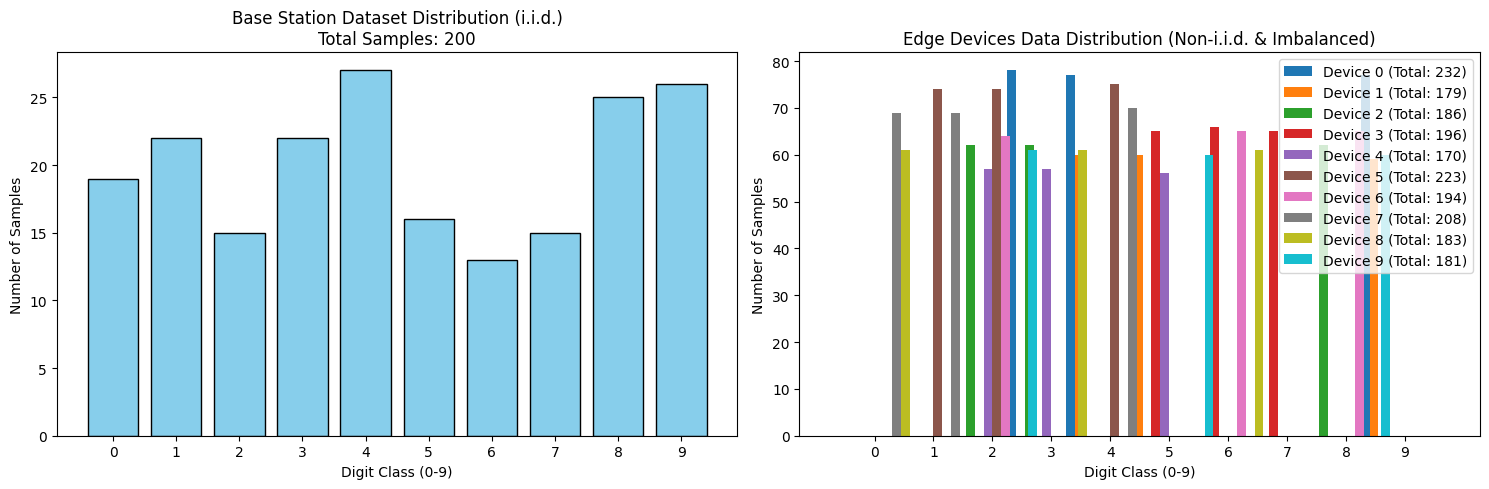

In [21]:
def plot_data_distribution(bs_dataset, client_datasets, num_clients_to_show=5):
    """
    Plots the label distribution for the Base Station and a few selected clients.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # --- 1. BS Dataset Distribution ---
    # Extract labels using the indices stored in the Subset
    bs_labels = [bs_dataset.dataset.targets[idx].item() for idx in bs_dataset.indices]
    bs_counts = np.bincount(bs_labels, minlength=10)
    
    axes[0].bar(range(10), bs_counts, color='skyblue', edgecolor='black')
    axes[0].set_title('Base Station Dataset Distribution (i.i.d.)\nTotal Samples: {}'.format(sum(bs_counts)))
    axes[0].set_xlabel('Digit Class (0-9)')
    axes[0].set_ylabel('Number of Samples')
    axes[0].set_xticks(range(10))
    
    # --- 2. Client Dataset Distribution (First few clients) ---
    width = 0.15 # Width of the bars for grouped charting
    x = np.arange(10)
    
    for i in range(num_clients_to_show):
        client_labels = [client_datasets[i].dataset.targets[idx].item() for idx in client_datasets[i].indices]
        client_counts = np.bincount(client_labels, minlength=10)
        
        # Offset each client's bars so they group nicely side-by-side
        axes[1].bar(x + (i - num_clients_to_show/2) * width + width/2, 
                    client_counts, 
                    width=width, 
                    label=f'Device {i} (Total: {sum(client_counts)})')
        
    axes[1].set_title(f'Edge Devices Data Distribution (Non-i.i.d. & Imbalanced)')
    axes[1].set_xlabel('Digit Class (0-9)')
    axes[1].set_ylabel('Number of Samples')
    axes[1].set_xticks(range(10))
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

# --- Run the visualization ---
# Generate the data
bs_dataset, client_datasets, test_dataset = get_dataset(K=K, M_0=M_0)

# Plot it
plot_data_distribution(bs_dataset, client_datasets, num_clients_to_show=10)


STARTING SIMULATION FOR M_0 = 50
Aggregating 300 devices over the air...
Round 1 Completed. Test Accuracy: 8.63% | Distortion: 0.5554
Round 2 Completed. Test Accuracy: 9.44% | Distortion: 0.5595
Round 3 Completed. Test Accuracy: 8.99% | Distortion: 0.5719
Round 4 Completed. Test Accuracy: 7.57% | Distortion: 0.5726
Round 5 Completed. Test Accuracy: 7.01% | Distortion: 0.5748
Round 6 Completed. Test Accuracy: 6.27% | Distortion: 0.5725
Round 7 Completed. Test Accuracy: 5.76% | Distortion: 0.5668
Round 8 Completed. Test Accuracy: 6.42% | Distortion: 0.5712
Round 9 Completed. Test Accuracy: 8.75% | Distortion: 0.5770
Round 10 Completed. Test Accuracy: 9.72% | Distortion: 0.5734
Round 11 Completed. Test Accuracy: 10.45% | Distortion: 0.5687
Round 12 Completed. Test Accuracy: 12.38% | Distortion: 0.5760
Round 13 Completed. Test Accuracy: 10.15% | Distortion: 0.5760
Round 14 Completed. Test Accuracy: 10.63% | Distortion: 0.5807
Round 15 Completed. Test Accuracy: 10.23% | Distortion: 0.5763


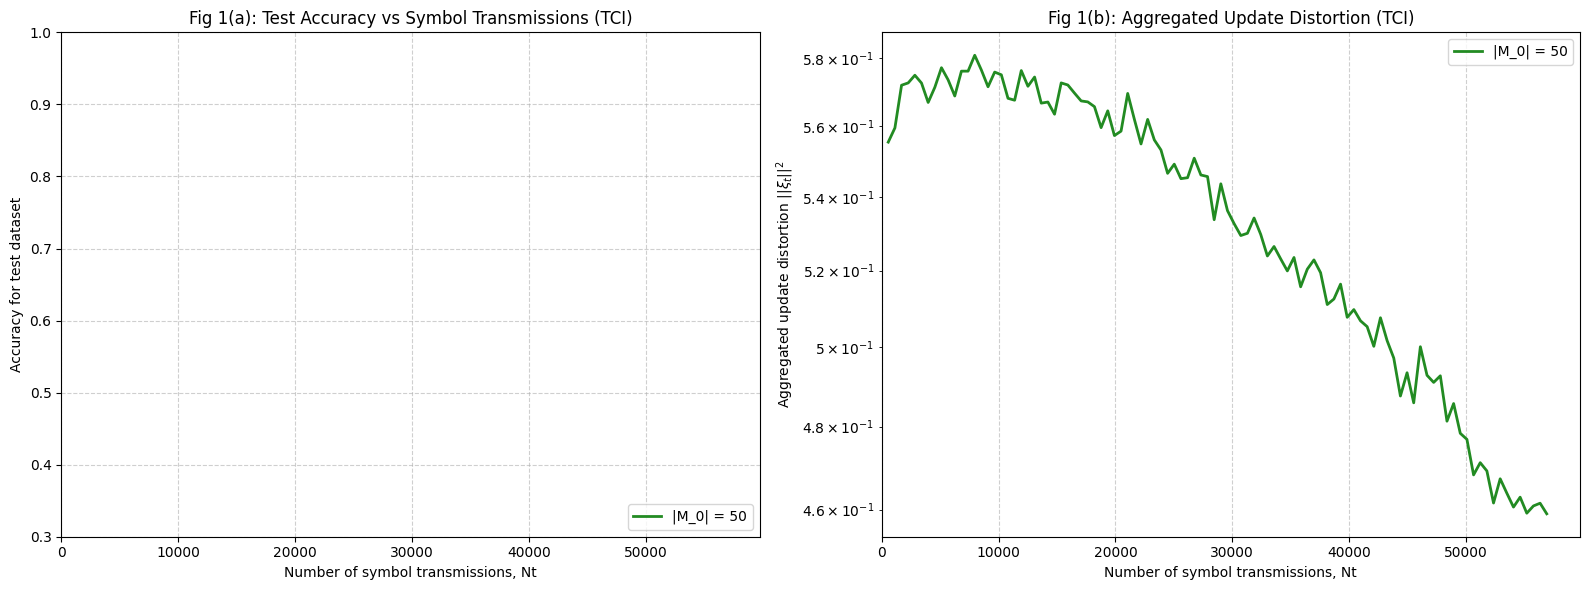

In [22]:
# --- Execution Code for Fig 1 (TCI Baseline) ---
if __name__ == "__main__":
    
    # 1. Use the full 300 devices
    K = 300
    
    # 2. Spread all 300 devices across the FULL 550m radius
    global_r_k_dist = np.clip(r_cvge * np.sqrt(np.random.rand(K)), 10.0, r_cvge)
    
    M0_values = [50]
    
    # Generate data ONCE
    max_m0 = max(M0_values)
    full_bs_data, global_client_data, test_data = get_dataset(K=K, M_0=max_m0)

    colors = {400: 'navy', 200: 'firebrick', 50: 'forestgreen', 10: 'purple'}
    results = {}
    N = int(np.ceil(D / F))

    # --- Run the 4 Simulations ---
    for m in M0_values:
        print(f"\n{'='*50}")
        print(f"STARTING SIMULATION FOR M_0 = {m}")
        print(f"{'='*50}")
        
        # Slice the Base Station data
        current_bs_indices = full_bs_data.indices[:m]
        bs_data = Subset(full_bs_data.dataset, current_bs_indices)

        # [THE FIX]: Notice there is NO 250m filter here! 
        # We pass K=300 and the full global_client_data directly into the function.
        
        final_model, Nt_list, acc_list, dist_list = run_ota_federated_learning(
            bs_data, global_client_data, test_data, 
            K=K,           # Uses all 300 devices
            D=D, F=F, 
            P_mW=P_mW, 
            r_k_dist=global_r_k_dist, 
            num_rounds=100
        )
        
        results[m] = {'Nt': Nt_list, 'acc': acc_list, 'dist': dist_list}

    # --- Plotting Both Figures Side-by-Side ---
    print("\nSimulations complete. Generating plots...")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    max_Nt = max(results[M0_values[0]]['Nt']) 
    x_limit = max_Nt + (N * 5)
    
    # Fig 1(a) Test Accuracy
    for m in M0_values:
        ax1.plot(results[m]['Nt'], results[m]['acc'], 
                 label=f'|M_0| = {m}', color=colors[m], linewidth=2)
        
    ax1.set_title('Fig 1(a): Test Accuracy vs Symbol Transmissions (TCI)')
    ax1.set_xlabel('Number of symbol transmissions, Nt')
    ax1.set_ylabel('Accuracy for test dataset')
    ax1.set_ylim(0.3, 1.0) 
    ax1.set_xlim(0, x_limit)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend(loc='lower right')
    
    # Fig 1(b) Aggregated Update Distortion
    for m in M0_values:
        ax2.plot(results[m]['Nt'], results[m]['dist'], 
                 label=f'|M_0| = {m}', color=colors[m], linewidth=2)
        
    ax2.set_title('Fig 1(b): Aggregated Update Distortion (TCI)')
    ax2.set_xlabel('Number of symbol transmissions, Nt')
    ax2.set_ylabel(r'Aggregated update distortion $||\xi_t||^2$')
    ax2.set_yscale('log')
    ax2.set_xlim(0, x_limit)
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()